# 05 · Pasting the Backlight mocks

Draws 128 parameter points from a proposal built on the theory-SBI posterior, pastes a
Backlight mock at each, measures it through the frozen estimator, and augments every point
with noise realisations drawn field-level on the real mask.

`mock_sbi_design.py` · `build_mock_sbi_observation.py` · `build_mock_sbi_noise_bank.py` ·
`measure_mock_sbi_pastes.py` · `build_mock_sbi_training_set.py` · `mock_sbi_sbatch/`

In [1]:
import json, pathlib, sys
import numpy as np, h5py
import matplotlib.pyplot as plt
ROOT = pathlib.Path("/mnt/ceph/users/spandey/ltu-godmax/GODMAX")
sys.path.insert(0, str(ROOT / "notebooks/SBI_validate/common"))
DATA = ROOT / "data/SBI_validate"
VAL  = DATA / "three_probe_mock/validation"
INF  = DATA / "three_probe_inference"
MSBI = DATA / "mock_sbi"
BLUE, ORANGE, GREEN, INK2, GRID = "#2a78d6", "#eb6834", "#1baf7a", "#52514e", "#dedcd6"
plt.rcParams.update({"figure.facecolor": "white", "axes.facecolor": "white",
                     "axes.edgecolor": GRID, "xtick.color": INK2, "ytick.color": INK2,
                     "font.size": 10.5, "axes.spines.top": False, "axes.spines.right": False})
SPECTRA = ["gy", "gkappa", "gtau"]
LBL = {"gg": r"$g \times g$", "gy": r"$g \times y$",
       "gkappa": r"$g \times \kappa_{\rm CMB}$", "gtau": r"$g \times \tau$"}

In [2]:
plan = json.loads((MSBI / "paste_plan/round_1/paste_plan.json").read_text())
PARAMS = ["theta_ej_0", "alpha_nt", "mu_beta", "theta_co_0", "nu_theta_ej_M"]
design = np.array([[e["theta"][p] for p in PARAMS] for e in plan["entries"]], float)
comp = {}
for e in plan["entries"]: comp[e["component"]] = comp.get(e["component"], 0) + 1
print(f"{design.shape[0]} design points")
for k, v in sorted(comp.items()): print(f"   {k:<12} {v:3d}  ({100*v/len(design):.0f}%)")

128 design points
   broadened     37  (29%)
   guide         63  (49%)
   prior         28  (22%)


### Where the design points sit\n\nThe proposal is a mixture: a guide component from the theory-SBI posterior, a broadened\ncomponent, and a prior component. The tails are deliberate — they keep the later NLE from\nextrapolating.

orange star = the generating point


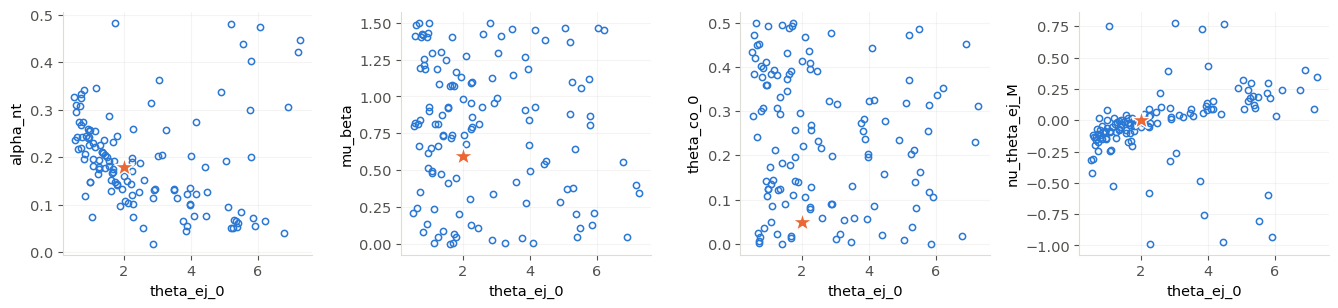

In [3]:
fig, axes = plt.subplots(1, 4, figsize=(13.5, 3.2))
for ax, j in zip(axes, range(1, 5)):
    ax.plot(design[:, 0], design[:, j], "o", ms=4.5, mfc="none", mec=BLUE, mew=1.1)
    ax.plot(2.0, [0.18, 0.6, 0.05, 0.0][j-1], "*", ms=15, color=ORANGE, mec="white")
    ax.set_xlabel(PARAMS[0]); ax.set_ylabel(PARAMS[j]); ax.grid(alpha=.3, color=GRID)
fig.tight_layout()
print("orange star = the generating point")

### The measured 42-vectors, and where the observation sits among them

94 pasted points measured; black = the mock observation
chi2 vs observation: min 43.9  median 664.7  max 3.12e+05


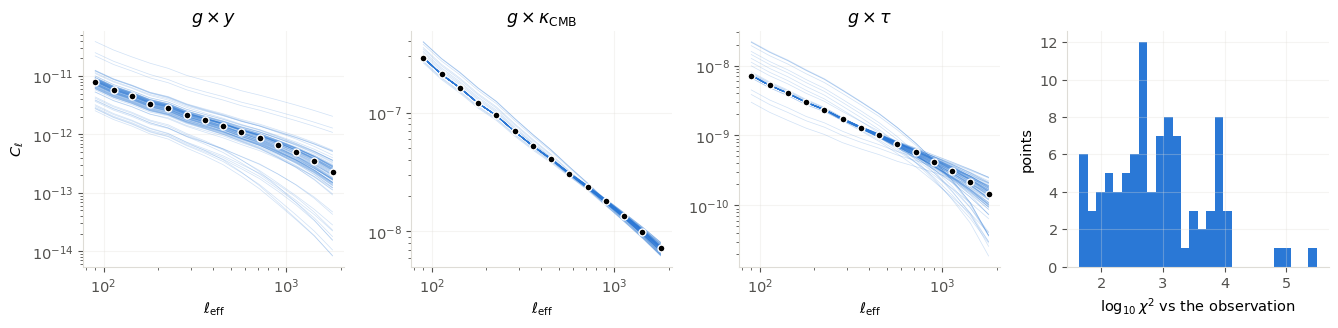

In [4]:
resp = np.load(MSBI / "trial/responses_n0038.npz", allow_pickle=True)
mu = np.asarray(resp["vectors"], float)
man = json.loads(str(resp["manifest_json"]))
chi2 = np.array([r["chi2_against_observation"] for r in man["records"]], float)
with h5py.File(INF / "observation_mock.h5", "r") as h:
    obs = np.asarray(h["data_vector"], float)
import mock_sbi_common as msc
ell = np.asarray(msc.load_estimator_context().effective_ell, float)
fig, axes = plt.subplots(1, 4, figsize=(13.5, 3.4))
for k, (ax, s) in enumerate(zip(axes[:3], SPECTRA)):
    sl = slice(14*k, 14*(k+1))
    ax.plot(ell, np.where(mu[:, sl] > 0, mu[:, sl], np.nan).T, color=BLUE, lw=.5, alpha=.22)
    ax.plot(ell, obs[sl], "o", ms=5, color="k", mec="white", mew=1.0)
    ax.set_xscale("log"); ax.set_yscale("log"); ax.set_title(LBL[s])
    ax.set_xlabel(r"$\ell_{\rm eff}$"); ax.grid(alpha=.3, color=GRID)
axes[0].set_ylabel(r"$C_\ell$")
axes[3].hist(np.log10(chi2), bins=28, color=BLUE)
axes[3].set_xlabel(r"$\log_{10}\chi^2$ vs the observation"); axes[3].set_ylabel("points")
axes[3].grid(alpha=.3, color=GRID)
fig.tight_layout()
print(f"{mu.shape[0]} pasted points measured; black = the mock observation")
print(f"chi2 vs observation: min {chi2.min():.1f}  median {np.median(chi2):.1f}  max {chi2.max():.3g}")

### Noise augmentation\n\nEach point is replicated with draws from a frozen bank; each draw is pushed through the\nreal estimator (`synalm -> alm2map -> mask -> map2alm -> decouple`), never an `L @ eps`\nshortcut in bandpower space.

In [5]:
tr = np.load(MSBI / "trial/training_set_n0038.npz", allow_pickle=True)
x, mu_pt = np.asarray(tr["x"], float), np.asarray(tr["mu"], float)
nrep = x.shape[0] // mu_pt.shape[0]
print(f"{x.shape[0]:,} training rows = {mu_pt.shape[0]} points x {nrep} draws")
print(f"bank reuse factor {x.shape[0]/2048:.2f}x")
cov = np.asarray(msc.load_estimator_context().covariance, float)
sd = np.sqrt(np.diag(cov))
resid = (x - np.repeat(mu_pt, nrep, axis=0)) / sd[None, :]
print(f"whitened noise per band: mean {resid.mean():+.4f}  sd {resid.std():.4f}  "
      f"(a correct draw gives 0 and ~0.96 for this bank)")

6,016 training rows = 94 points x 64 draws
bank reuse factor 2.94x


whitened noise per band: mean -0.0062  sd 0.9606  (a correct draw gives 0 and ~0.96 for this bank)
